# Poisson-GLM

This notebook implements Generalized Linear Model (GLM) analysis inspired by the neuroGLM toolkit (https://github.com/memming/neuroGLM) and the methodology from:

**Park et al. (2014). "Encoding and decoding in parietal cortex during sensorimotor decision-making." Nature Neuroscience 17, 1395-1403.**



In [13]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
from scipy.io import loadmat
from scipy import stats, signal
from scipy.sparse import csr_matrix, vstack, hstack, issparse
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


In [15]:
from imports import *
from src.utils import poisson_glm_utils
from config import dir_config
from config.poisson_glm_config import StateBasedPoissonGLMConfig

In [16]:
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)
models_dir = Path(processed_dir, 'poisson_glm', 'models')

# Discover all model folders that contain neuron files
model_names = sorted([
    d.name for d in models_dir.iterdir()
    if d.is_dir() and any(f.name.startswith('neuron_') for f in d.iterdir())
])
print(f"Found {len(model_names)} models: {model_names}")

# remove models which has 1coh in it's name
model_names = [m for m in model_names if "1coh" not in m]
print(f"After filtering, {len(model_names)} models remain: {model_names}")

session_to_exclude = ["210210_GP_JP", "241209_GP_TZ"]

session_metadata = pd.read_csv(Path(processed_dir, 'sessions_metadata.csv'))
session_metadata = session_metadata[~np.isin(session_metadata["session_id"], session_to_exclude)]

neuron_metadata = pd.read_csv(Path(processed_dir, 'neuron_metadata.csv'))
neuron_metadata = neuron_metadata[~np.isin(neuron_metadata["session_id"], session_to_exclude)].reset_index()


Found 7 models: ['0stim_2choice_1500ms', '1stim_1coh_0choice', '1stim_1coh_2choice_1500ms', '1stim_7coh_0choice', '1stim_7coh_2choice_1500ms', '7stim_7coh_0choice', '7stim_7coh_2choice_1500ms']
After filtering, 5 models remain: ['0stim_2choice_1500ms', '1stim_7coh_0choice', '1stim_7coh_2choice_1500ms', '7stim_7coh_0choice', '7stim_7coh_2choice_1500ms']


In [17]:
alignment_settings = {
    "visual": { "event": "target_onset", "start_time_ms": -50, "end_time_ms": 250 },
    "cue": { "event": "stimulus_onset", "start_time_ms": -100, "end_time_ms": 800 },
    "response": { "event": "response_onset", "start_time_ms": -300, "end_time_ms": 0 },
}
# coh_levels = result['coh_levels']

### Helper Functions

In [18]:
def spike_train_convolved(trial_info, pred, alignment_settings, alignment_buffer=0):
    convolved_spike_density = []
    predicted_spike_rate = []
    sigma = 10  # 10ms smoothing

    for alignment_idx, key in enumerate(alignment_settings):
        convolved_spike_density.append(np.zeros([len(trial_info), alignment_settings[key]["end_time_ms"] - alignment_settings[key]["start_time_ms"] + 2 * alignment_buffer]))
        predicted_spike_rate.append(np.zeros([len(trial_info), alignment_settings[key]["end_time_ms"] - alignment_settings[key]["start_time_ms"]]))

        for idx in range(len(trial_info)):
            start_timestamp = int(trial_info.loc[idx, alignment_settings[key]["event"]] + (alignment_settings[key]["start_time_ms"] - alignment_buffer))
            end_timestamp = int(trial_info.loc[idx, alignment_settings[key]["event"]] + (alignment_settings[key]["end_time_ms"] + alignment_buffer))

            trial_spike_train = trial_info.loc[idx, "spike_train"]
            trial_predicted_rate = pred[idx]

            end_timestamp = min(end_timestamp, len(trial_spike_train))
            trial_spike_train = trial_spike_train[start_timestamp:end_timestamp]
            trial_predicted_rate = trial_predicted_rate[start_timestamp + alignment_buffer:end_timestamp-alignment_buffer] # not buffering for predicted rate
            convolved_spike_density[alignment_idx][idx, :len(trial_spike_train)] = gaussian_filter1d(trial_spike_train, sigma=sigma, truncate=3)  # gaussian smoothened
            predicted_spike_rate[alignment_idx][idx,:len(trial_predicted_rate)] = gaussian_filter1d(trial_predicted_rate, sigma=sigma, truncate=3)

            if alignment_settings[key]["event"] == "stimulus_onset":
                if (end_timestamp - alignment_buffer) > trial_info.loc[idx, "response_onset"] - 50 :  # exclude spikes after -50ms aligned to saccade
                    pre_saccade_idx = np.ceil((end_timestamp - trial_info.loc[idx, "response_onset"])+ 50 - alignment_buffer).astype(int)
                    convolved_spike_density[alignment_idx][idx, -pre_saccade_idx:] = np.nan
                    predicted_spike_rate[alignment_idx][-pre_saccade_idx-alignment_buffer:] = np.nan

            # elif alignment_settings[alignment_idx]['alignment_event'] == 'response_onset':
            #     if start_timestamp <

        convolved_spike_density[alignment_idx] = convolved_spike_density[alignment_idx][:, alignment_buffer:convolved_spike_density[alignment_idx].shape[1]-alignment_buffer] * 1000
        predicted_spike_rate[alignment_idx] *= 1000

    return convolved_spike_density, predicted_spike_rate


In [19]:
def variance_explained(y_true, y_pred):
    """
    Compute variance explained for neural predictions.

    Parameters
    ----------
    y_true : array-like
        True spike counts or firing rate (can be per bin or per trial)
    y_pred : array-like
        Predicted spike counts or firing rate (same shape as y_true)

    Returns
    -------
    ve : float
        Variance explained, between -inf and 1.0
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Remove NaNs if any
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    # Compute residual variance
    residual_var = np.var(y_true - y_pred, ddof=0)
    total_var = np.var(y_true, ddof=0)

    ve = 1 - residual_var / total_var
    return ve

### Load data

In [20]:
# Stream one neuron at a time — never holds more than one file in memory
for model in model_names:
    model_dir = Path(models_dir, model)
    neuron_files = sorted(model_dir.glob('neuron_*'), key=lambda p: int(p.name.split('_')[1]))
    col = f'r2_{model}'
    print(f"Processing model: {model}  ({len(neuron_files)} neurons)")

    for file_path in neuron_files:
        nid = int(file_path.name.split('_')[1])

        with open(file_path, 'rb') as f:
            fitting_result = pickle.load(f)

        trial_info = pd.DataFrame()
        test_pred = []
        for fold_result in fitting_result["folds"]:
            test_pred.extend(fold_result['test_predictions'])
            trial_info = pd.concat([trial_info, fold_result['test_data']], ignore_index=True)

        del fitting_result  # free memory immediately

        convolved_spike_density, predicted_spike_rate = spike_train_convolved(
            trial_info, test_pred, alignment_settings
        )
        r2 = variance_explained(
            np.nanmean(np.hstack(convolved_spike_density), axis=0),
            np.nanmean(np.hstack(predicted_spike_rate), axis=0)
        )
        neuron_metadata.loc[neuron_metadata.neuron_id == nid, col] = r2

print("Done.")


Processing model: 0stim_2choice_1500ms  (166 neurons)
Processing model: 1stim_7coh_0choice  (166 neurons)
Processing model: 1stim_7coh_2choice_1500ms  (166 neurons)
Processing model: 7stim_7coh_0choice  (166 neurons)
Processing model: 7stim_7coh_2choice_1500ms  (166 neurons)
Done.


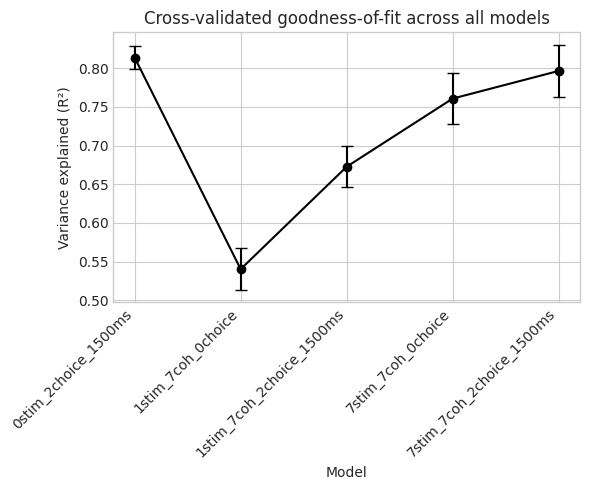

In [21]:
def remove_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3.0 * iqr
    upper = q3 + 3.0 * iqr
    return series[(series >= lower) & (series <= upper)]

fig, ax = plt.subplots(1, 1, figsize=(max(6, len(model_names) * 1.2), 5))

x = np.arange(len(model_names))
medians = []
errors = []

for model in model_names:
    raw_data = neuron_metadata[f'r2_{model}'].dropna()
    clean_data = remove_outliers_iqr(raw_data)
    medians.append(clean_data.median())
    errors.append(clean_data.std() / np.sqrt(len(clean_data)))

ax.errorbar(x, medians, yerr=errors, marker='o', linestyle='-', color='k', capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_xlabel('Model')
ax.set_ylabel('Variance explained (R²)')
ax.set_title('Cross-validated goodness-of-fit across all models')

plt.tight_layout()
plt.show()


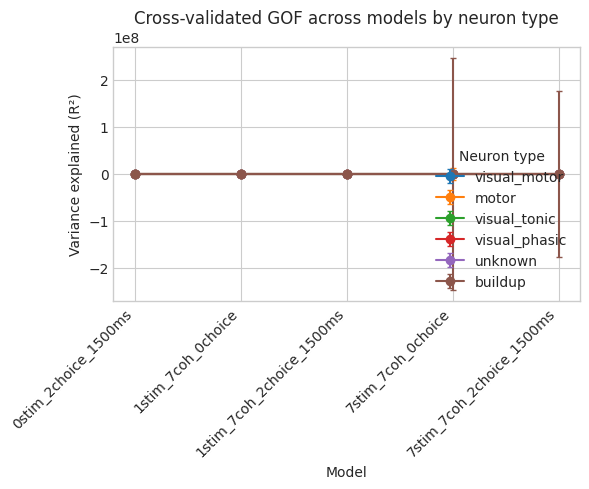

In [22]:
def remove_outliers_quantile(series, low_q=0.01, high_q=1):
    """Remove values outside the quantile range."""
    lower = series.quantile(low_q)
    upper = series.quantile(high_q)
    return series[(series >= lower) & (series <= upper)]

fig, ax = plt.subplots(1, 1, figsize=(max(6, len(model_names) * 1.2), 5))

x = np.arange(len(model_names))
classes = neuron_metadata['classification'].dropna().unique()
cmap = plt.get_cmap('tab10')

for ci, cls in enumerate(classes):
    class_data = neuron_metadata[neuron_metadata['classification'] == cls]
    medians = []
    errors = []

    for model in model_names:
        raw_data = class_data[f'r2_{model}'].dropna()
        clean_data = remove_outliers_quantile(raw_data)
        medians.append(clean_data.median())
        errors.append(clean_data.std() / np.sqrt(len(clean_data)))

    ax.errorbar(x, medians, yerr=errors, marker='o', linestyle='-',
                label=str(cls), color=cmap(ci), capsize=2)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_xlabel('Model')
ax.set_ylabel('Variance explained (R²)')
ax.set_title('Cross-validated GOF across models by neuron type')
ax.legend(title='Neuron type', loc='lower right')

plt.tight_layout()
plt.show()


In [23]:
neuron_metadata['classification'].value_counts()

classification
visual_motor     43
unknown          40
motor            33
buildup          30
visual_phasic    10
visual_tonic     10
Name: count, dtype: int64